# MODIS Multi-Algorithm Comparison Analysis with 5-Day Matching Window

This notebook compares **four different algorithms**:
1. **Multi-term**: log₁₀(Chl_insitu) = α₀ + α₁×log₁₀(B4/B1) + α₂×(B2/B1)
2. **Green/Red Log**: log₁₀(Chl_insitu) = α₀ + α₁×log₁₀(B4/B1) 
3. **Simple Green/Red**: Chl_insitu = α₀ + α₁×(B4/B1)
4. **Simple NIR/Red**: Chl_insitu = α₀ + α₁×(B2/B1)

All use **5-day matching window** and **enhanced outlier detection**.

In [1]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import all functions from the merged utilities module
from modis_calibration_utils import (
    # Algorithm comparison functions
    match_satellite_insitu_5day,
    compare_algorithms,
    calibrate_multiterm_model,
    calibrate_greenred_model,
    calibrate_simple_ratio,
    apply_multiterm_calibration,
    apply_greenred_calibration,
    apply_simple_ratio_calibration,
    # Other utilities functions
    create_time_series_plot,
    export_calibrated_data,
    load_detroit_ysi_data
)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
print("MODIS Multi-Algorithm Comparison Analysis - Libraries loaded successfully!")

MODIS Multi-Algorithm Comparison Analysis - Libraries loaded successfully!


## 1. Load UKL in situ data using existing function

In [2]:
try:
    from load_ukl_data import load_ukl_insitu_data, filter_ukl_data_for_satellite_calibration
    
    # Load in situ UKL data using existing function
    raw_ukl_data = load_ukl_insitu_data()
    if len(raw_ukl_data) == 0:
        raise Exception("No UKL data loaded")
    
    # Filter for satellite calibration
    ukl_insitu = filter_ukl_data_for_satellite_calibration(raw_ukl_data, min_chl=1.0, max_chl=350.0)
    
    # Ensure proper column names
    if 'datetime' not in ukl_insitu.columns and 'date' in ukl_insitu.columns:
        ukl_insitu['datetime'] = pd.to_datetime(ukl_insitu['date'])
    
    print(f"In situ UKL data loaded: {len(ukl_insitu)} records")
    print(f"Date range: {ukl_insitu['datetime'].min()} to {ukl_insitu['datetime'].max()}")
    print(f"Chlorophyll range: {ukl_insitu['chlorophyll_ugL'].min():.1f} - {ukl_insitu['chlorophyll_ugL'].max():.1f} µg/L")
    
except Exception as e:
    print(f"Could not load UKL data using load_ukl_data.py: {e}")
    print("Falling back to CSV file loading...")
    
    # Fallback to direct CSV loading
    try:
        ukl_csv_path = 'UKL_insitu_chlorophyll.csv'
        raw_data = pd.read_csv(ukl_csv_path)
        raw_data['datetime'] = pd.to_datetime(raw_data['date'], errors='coerce')
        raw_data = raw_data.dropna(subset=['datetime', 'chlorophyll_ugL'])
        
        # Filter for satellite calibration
        ukl_insitu = raw_data[
            (raw_data['chlorophyll_ugL'] >= 1.0) & 
            (raw_data['chlorophyll_ugL'] <= 350.0)
        ].copy()
        
        print(f"UKL data loaded from CSV: {len(ukl_insitu)} records")
        
    except Exception as e2:
        print(f"Error loading UKL data from CSV: {e2}")
        ukl_insitu = None

# Load Detroit YSI data
print("\nLoading Detroit YSI data...")
detroit_insitu = load_detroit_ysi_data()

Loading UKL in situ data from: /Users/todd/GitHub/ecohydrology/CE-QUAL-W2-HAB-Capabilities/Data/Upper_Klamath_Lake/Klamath K.csv
Found 1486 chlorophyll measurements

Data Summary:
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 0.8 - 1341.3 µg/L
Mean chlorophyll: 57.5 µg/L
Median chlorophyll: 23.9 µg/L
Organizations: ['CEDEN' 'KLAMATHTRIBES_WQX']
Number of unique locations: 22
Filtering results:
  Initial records: 1486
  Final records: 1469
  Removed: 17 (1.1%)
In situ UKL data loaded: 1469 records
Date range: 2011-04-18 00:00:00 to 2018-10-23 00:00:00
Chlorophyll range: 1.6 - 344.4 µg/L

Loading Detroit YSI data...
Detroit YSI data loaded: 7029 measurements
Date range: 2010-06-29 10:21:00 to 2022-09-06 11:15:53
Chlorophyll range: 0.0 - 17.4 µg/L


## 2. Load MODIS Satellite Data

In [3]:
# Load MODIS satellite data
def load_modis_data(file_paths):
    """
    Load MODIS data from multiple files
    
    Args:
        file_paths: Dictionary with sensor names as keys and file paths as values
    """
    modis_data = {}
    
    for sensor_name, file_path in file_paths.items():
        try:
            df = pd.read_csv(file_path)
            df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
            df = df.dropna(subset=['datetime'])
            df = df.sort_values('datetime').reset_index(drop=True)
            
            # Add sensor label
            df['sensor'] = sensor_name
            
            modis_data[sensor_name] = df
            print(f"{sensor_name}: {len(df)} records")
            
        except Exception as e:
            print(f"Error loading {sensor_name} data: {e}")
            modis_data[sensor_name] = None
    
    return modis_data

# Define file paths - UPDATE THESE TO MATCH YOUR FILE STRUCTURE
ukl_files = {
    'UKL-Terra': 'UKL_MODIS_Multiband_Terra.csv',
    'UKL-Aqua': 'UKL_MODIS_Multiband_Aqua.csv'
}

detroit_files = {
    'Detroit-Terra': 'Detroit_Mid-Lake_MODIS_Multiband_Terra.csv',
    'Detroit-Aqua': 'Detroit_Mid-Lake_MODIS_Multiband_Aqua.csv'
}

print("Loading UKL MODIS data for calibration:")
ukl_modis = load_modis_data(ukl_files)

print("\nLoading Detroit MODIS data for application:")
detroit_modis = load_modis_data(detroit_files)

Loading UKL MODIS data for calibration:
UKL-Terra: 2497 records
UKL-Aqua: 2395 records

Loading Detroit MODIS data for application:
Detroit-Terra: 1931 records
Detroit-Aqua: 2002 records


## 3. Band Ratio Analysis and Calibration

In [4]:
# Analyze different band combinations
def analyze_band_ratios(modis_data, lake_name):
    """Analyze spectral band ratios for a lake"""
    print(f"\n=== {lake_name} Band Ratio Analysis ===")
    
    all_data = []
    for sensor_name, df in modis_data.items():
        if df is not None and len(df) > 0:
            all_data.append(df)
    
    if not all_data:
        print("No data available for analysis")
        return None
    
    # Combine all sensor data
    combined = pd.concat(all_data, ignore_index=True)
    
    # Calculate band ratios
    combined['green_red_ratio'] = combined['band4_green'] / combined['band1_red']
    combined['nir_red_ratio'] = combined['band2_nir'] / combined['band1_red']
    combined['log_green_red'] = np.log10(combined['green_red_ratio'])
    combined['log_nir_red'] = np.log10(combined['nir_red_ratio'])
    
    # Statistics
    print(f"Green/Red ratio: {combined['green_red_ratio'].mean():.3f} ± {combined['green_red_ratio'].std():.3f}")
    print(f"NIR/Red ratio: {combined['nir_red_ratio'].mean():.3f} ± {combined['nir_red_ratio'].std():.3f}")
    print(f"Log Green/Red: {combined['log_green_red'].mean():.3f} ± {combined['log_green_red'].std():.3f}")
    print(f"Log NIR/Red: {combined['log_nir_red'].mean():.3f} ± {combined['log_nir_red'].std():.3f}")
    
    return combined

# Analyze band ratios
ukl_analysis = analyze_band_ratios(ukl_modis, "Upper Klamath Lake")
detroit_analysis = analyze_band_ratios(detroit_modis, "Detroit Lake")


=== Upper Klamath Lake Band Ratio Analysis ===
Green/Red ratio: 1.485 ± 2.420
NIR/Red ratio: 0.643 ± 2.299
Log Green/Red: 0.138 ± 0.123
Log NIR/Red: -0.360 ± 0.319

=== Detroit Lake Band Ratio Analysis ===
Green/Red ratio: 1.515 ± 0.318
NIR/Red ratio: 4.751 ± 2.437
Log Green/Red: 0.170 ± 0.095
Log NIR/Red: 0.627 ± 0.213


## 4. Multi-Algorithm Comparison with 5-Day Matching Window

In [5]:
# Enhanced matching with 5-day window and multi-term calibration
print("=== MULTI-TERM CALIBRATION WITH 5-DAY MATCHING WINDOW ===")

# Step 1: Match satellite and in situ data with 5-day window
print("\n1. Matching satellite data with in situ measurements (5-day window)...")

all_ukl_matches_5day = []

for sensor_name, modis_df in ukl_modis.items():
    if modis_df is not None and len(modis_df) > 0:
        print(f"\nProcessing {sensor_name}:")
        
        # Use 5-day matching window
        matches_5day = match_satellite_insitu_5day(
            modis_df, 
            ukl_insitu, 
            temporal_window_days=5
        )
        
        if len(matches_5day) > 0:
            matches_5day['sensor_name'] = sensor_name
            all_ukl_matches_5day.append(matches_5day)
            print(f"  5-day matches: {len(matches_5day)}")
            
            # Show temporal distribution
            avg_time_diff = matches_5day['time_diff_days'].mean()
            max_time_diff = matches_5day['time_diff_days'].max()
            print(f"  Average time difference: {avg_time_diff:.1f} days")
            print(f"  Maximum time difference: {max_time_diff:.1f} days")
        else:
            print(f"  No matches found for {sensor_name}")

if all_ukl_matches_5day:
    ukl_matched_5day = pd.concat(all_ukl_matches_5day, ignore_index=True)
    print(f"\nTotal 5-day matched pairs: {len(ukl_matched_5day)}")
    
    # Show overall statistics
    print(f"Time difference statistics:")
    print(f"  Mean: {ukl_matched_5day['time_diff_days'].mean():.1f} days")
    print(f"  Median: {ukl_matched_5day['time_diff_days'].median():.1f} days") 
    print(f"  Max: {ukl_matched_5day['time_diff_days'].max():.1f} days")
    
else:
    print("No 5-day matches found - check data compatibility")
    ukl_matched_5day = None

=== MULTI-TERM CALIBRATION WITH 5-DAY MATCHING WINDOW ===

1. Matching satellite data with in situ measurements (5-day window)...

Processing UKL-Terra:
  5-day matches: 947
  Average time difference: 2.7 days
  Maximum time difference: 5.0 days

Processing UKL-Aqua:
  5-day matches: 914
  Average time difference: 2.7 days
  Maximum time difference: 5.0 days

Total 5-day matched pairs: 1861
Time difference statistics:
  Mean: 2.7 days
  Median: 3.0 days
  Max: 5.0 days


In [6]:
# Compare all algorithms on the same matched data
algorithm_results = {}

if ukl_matched_5day is not None and len(ukl_matched_5day) > 0:
    print("=== MULTI-ALGORITHM COMPARISON ===")
    
    # Compare algorithms for each sensor separately
    for sensor_name in ukl_matched_5day['sensor_name'].unique():
        sensor_data = ukl_matched_5day[ukl_matched_5day['sensor_name'] == sensor_name]
        
        if len(sensor_data) >= 20:  # Need enough data points
            print(f"\nComparing algorithms for {sensor_name}...")
            
            # Use the comparison function to test all algorithms
            sensor_algorithms = compare_algorithms(sensor_data, sensor_name)
            algorithm_results[sensor_name] = sensor_algorithms
        else:
            print(f"Not enough data for {sensor_name}: {len(sensor_data)} matches")
    
    # Also compare on combined data
    if len(ukl_matched_5day) >= 40:
        print(f"\nComparing algorithms on combined sensor data...")
        combined_algorithms = compare_algorithms(ukl_matched_5day, "MODIS-Combined")
        algorithm_results['Combined'] = combined_algorithms
    
else:
    print("No matched data available for algorithm comparison")

=== MULTI-ALGORITHM COMPARISON ===

Comparing algorithms for UKL-Terra...
\n================================================================================
ALGORITHM COMPARISON FOR UKL-Terra

MULTI-TERM CALIBRATION: UKL-Terra
Initial clean matches: 947
Outliers detected: 11

Calibration Results:
  Equation: log10(Chl) = 1.063 + 2.860*log10(B4/B1) + 0.126*(B2/B1)
  Original data: 947 matches, R² = 0.256, RMSE = 0.438
  Cleaned data: 936 matches, R² = 0.362, RMSE = 0.402
  Improvement: ΔR² = +0.106

GREEN/RED ONLY CALIBRATION: UKL-Terra
Initial clean matches: 947
Outliers detected: 11

Calibration Results:
  Equation: log10(Chl) = 1.090 + 3.218*log10(B4/B1)
  Original data: 947 matches, R² = 0.190, RMSE = 0.457
  Cleaned data: 936 matches, R² = 0.362, RMSE = 0.402
  Improvement: ΔR² = +0.171

SIMPLE GREEN_RED RATIO CALIBRATION: UKL-Terra
Initial clean matches: 947
Outliers detected: 1
\nCalibration Results:
  Equation: Chl = -64.235 + 78.058*(GREEN_RED_ratio)
  Original data: 947 matche

## 5. Apply Best Algorithm to Full Datasets

In [7]:
# Find the best performing algorithm and apply it to all data
def find_best_algorithm(algorithm_results):
    """Find the algorithm with highest R² across all sensors"""
    best_alg = None
    best_r2 = -1
    best_sensor = None
    
    for sensor_name, algorithms in algorithm_results.items():
        for alg_name, result in algorithms.items():
            if result is not None:
                r2 = result['cleaned']['r2']
                if r2 > best_r2:
                    best_r2 = r2
                    best_alg = alg_name
                    best_sensor = sensor_name
    
    return best_alg, best_r2, best_sensor

# Apply multiple algorithms to datasets for comparison
def apply_all_algorithms_to_dataset(modis_data, algorithm_results, dataset_name):
    """Apply all calibrated algorithms to a complete dataset"""
    print(f"\nApplying all algorithms to {dataset_name}...")
    
    all_calibrated_data = {}
    
    # Get the best combined algorithm to use for all data
    if 'Combined' in algorithm_results:
        algorithms_to_use = algorithm_results['Combined']
    else:
        # Use the first available sensor's algorithms
        algorithms_to_use = list(algorithm_results.values())[0]
    
    for sensor_name, modis_df in modis_data.items():
        if modis_df is None or len(modis_df) == 0:
            continue
            
        print(f"\nProcessing {sensor_name}:")
        sensor_results = {}
        
        # Apply each algorithm
        for alg_name, alg_result in algorithms_to_use.items():
            if alg_result is not None:
                try:
                    if alg_name == 'multiterm':
                        df_cal = apply_multiterm_calibration(modis_df, alg_result, f'chl_{alg_name}')
                    elif alg_name == 'greenred_log':
                        df_cal = apply_greenred_calibration(modis_df, alg_result, f'chl_{alg_name}')
                    elif alg_name in ['greenred_simple', 'nirred_simple']:
                        df_cal = apply_simple_ratio_calibration(modis_df, alg_result, f'chl_{alg_name}')
                    
                    sensor_results[alg_name] = df_cal
                    print(f"  {alg_name}: {len(df_cal)} valid observations")
                    
                    if len(df_cal) > 0:
                        chl_stats = df_cal[f'chl_{alg_name}'].describe()
                        print(f"    Range: {chl_stats['min']:.1f} - {chl_stats['max']:.1f} µg/L")
                        print(f"    Mean: {chl_stats['mean']:.1f} µg/L")
                except Exception as e:
                    print(f"  {alg_name}: FAILED ({e})")
                    sensor_results[alg_name] = None
        
        all_calibrated_data[sensor_name] = sensor_results
    
    return all_calibrated_data

# Apply algorithms and find the best one
if algorithm_results:
    best_algorithm, best_r2, best_sensor = find_best_algorithm(algorithm_results)
    print(f"\n🏆 BEST PERFORMING ALGORITHM:")
    print(f"   Algorithm: {best_algorithm}")
    print(f"   R² = {best_r2:.3f}")
    print(f"   From sensor: {best_sensor}")
    
    # Apply all algorithms to both datasets for comparison
    ukl_all_calibrated = apply_all_algorithms_to_dataset(ukl_modis, algorithm_results, "UKL")
    detroit_all_calibrated = apply_all_algorithms_to_dataset(detroit_modis, algorithm_results, "Detroit")
else:
    print("No algorithm results available")


🏆 BEST PERFORMING ALGORITHM:
   Algorithm: multiterm
   R² = 0.420
   From sensor: UKL-Aqua

Applying all algorithms to UKL...

Processing UKL-Terra:
  multiterm: 2477 valid observations
    Range: 1.4 - 993.3 µg/L
    Mean: 43.8 µg/L
  greenred_log: 2481 valid observations
    Range: 0.0 - 837.6 µg/L
    Mean: 42.0 µg/L
  greenred_simple: 2446 valid observations
    Range: 0.2 - 630.6 µg/L
    Mean: 44.9 µg/L
  nirred_simple: 2489 valid observations
    Range: 2.6 - 937.7 µg/L
    Mean: 45.7 µg/L

Processing UKL-Aqua:
  multiterm: 2385 valid observations
    Range: 0.7 - 933.6 µg/L
    Mean: 46.2 µg/L
  greenred_log: 2384 valid observations
    Range: 0.4 - 881.4 µg/L
    Mean: 45.4 µg/L
  greenred_simple: 2363 valid observations
    Range: 0.4 - 849.6 µg/L
    Mean: 47.3 µg/L
  nirred_simple: 2392 valid observations
    Range: 2.0 - 811.0 µg/L
    Mean: 40.9 µg/L

Applying all algorithms to Detroit...

Processing Detroit-Terra:
  multiterm: 1802 valid observations
    Range: 4.2 - 9


Creating Multi-term time series plot for UKL...


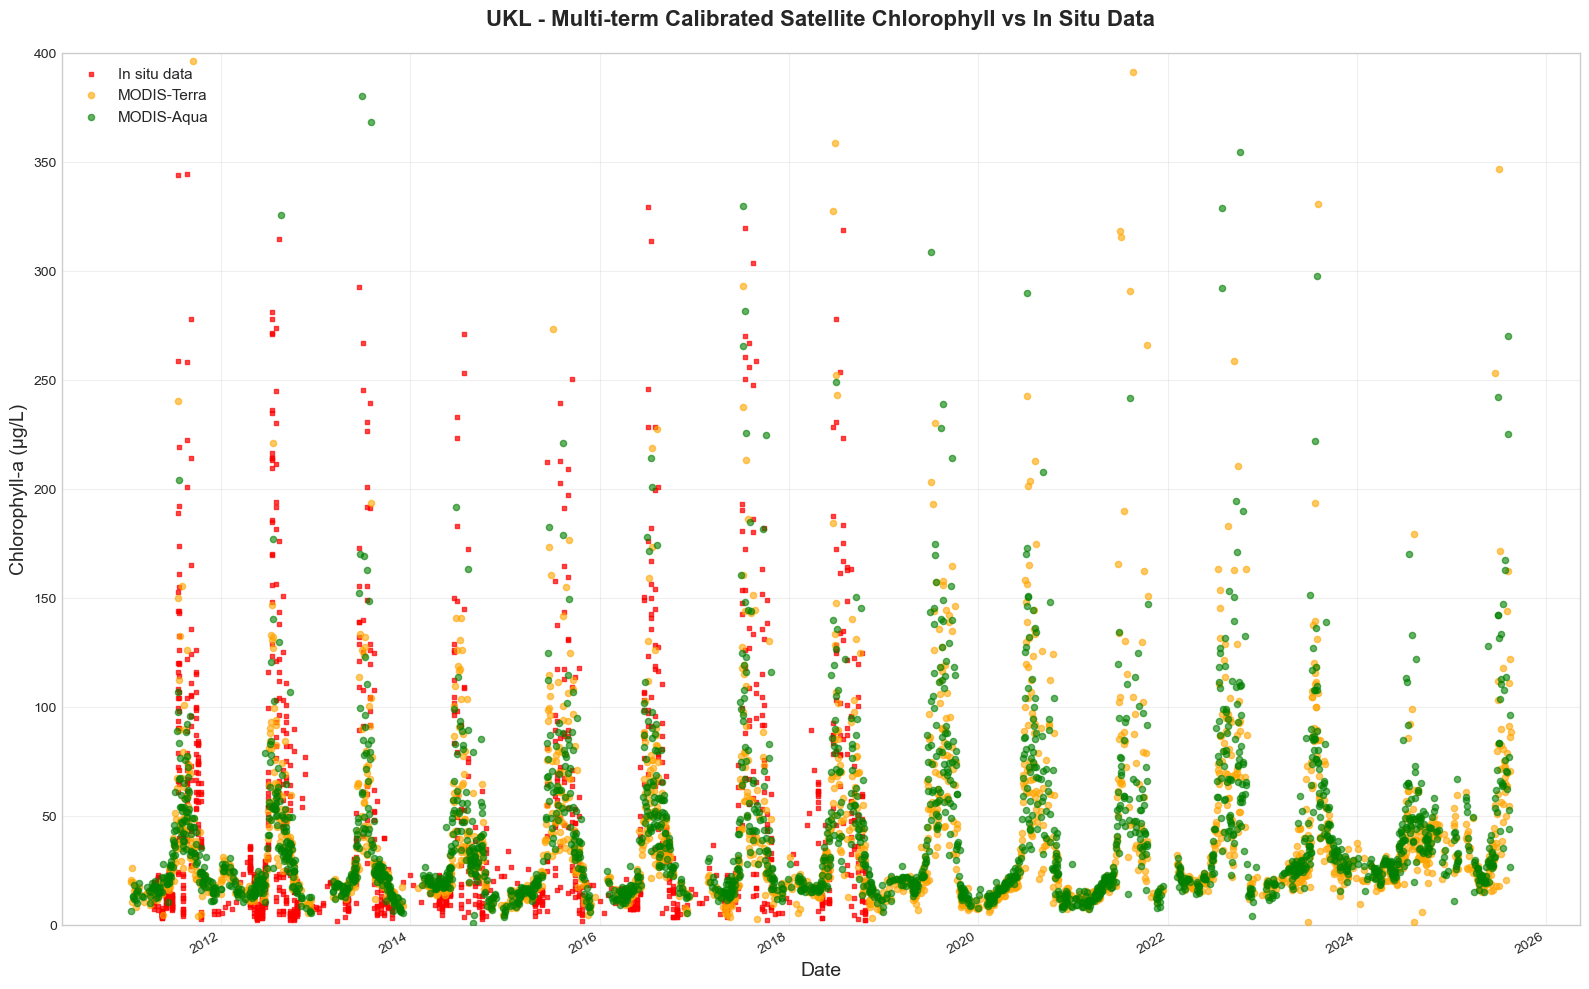

Plot saved: UKL_multiterm_comparison_time_series.png

Creating Green/Red Log time series plot for UKL...


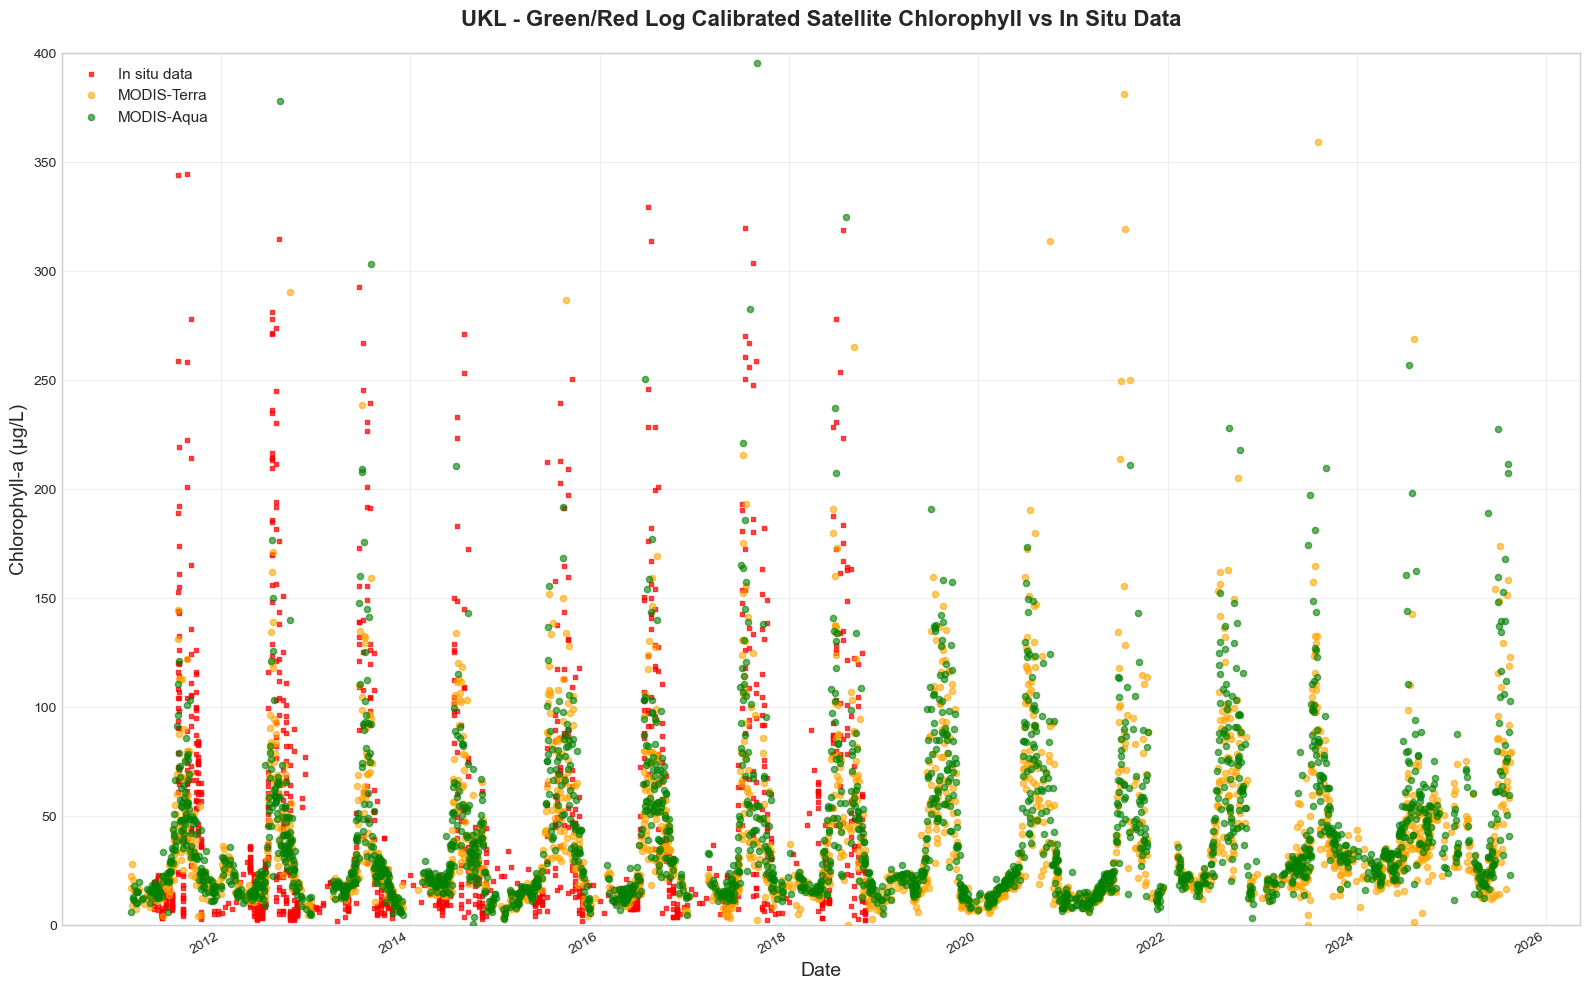

Plot saved: UKL_greenred_log_comparison_time_series.png

Creating Green/Red Simple time series plot for UKL...


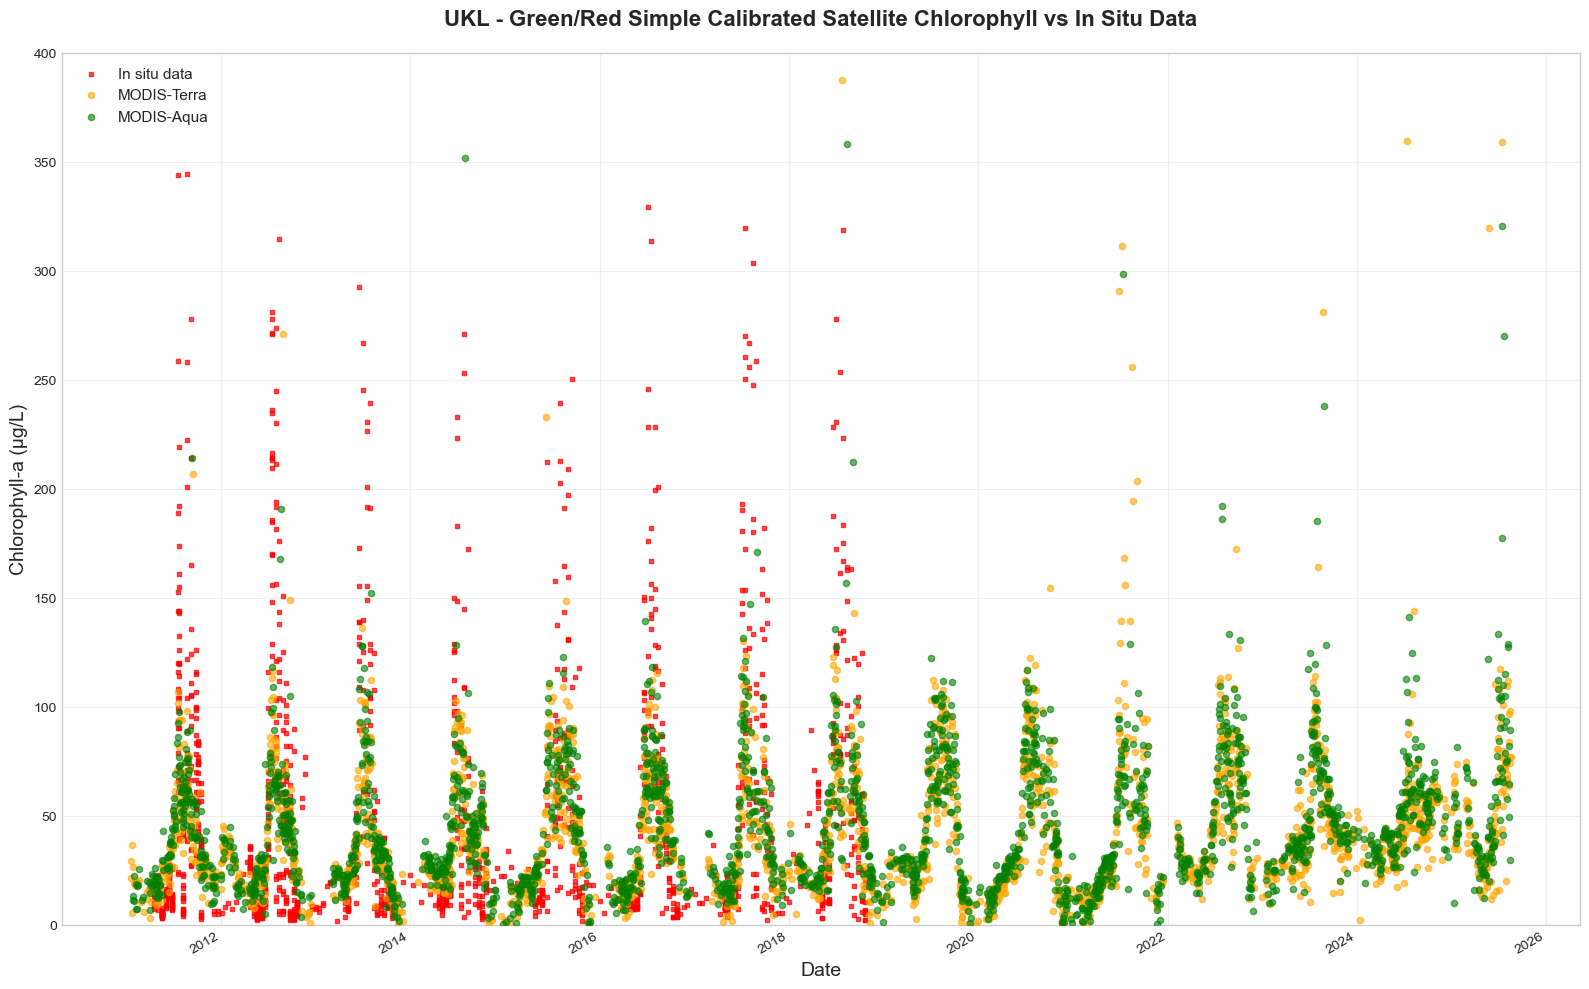

Plot saved: UKL_greenred_simple_comparison_time_series.png

Creating NIR/Red Simple time series plot for UKL...


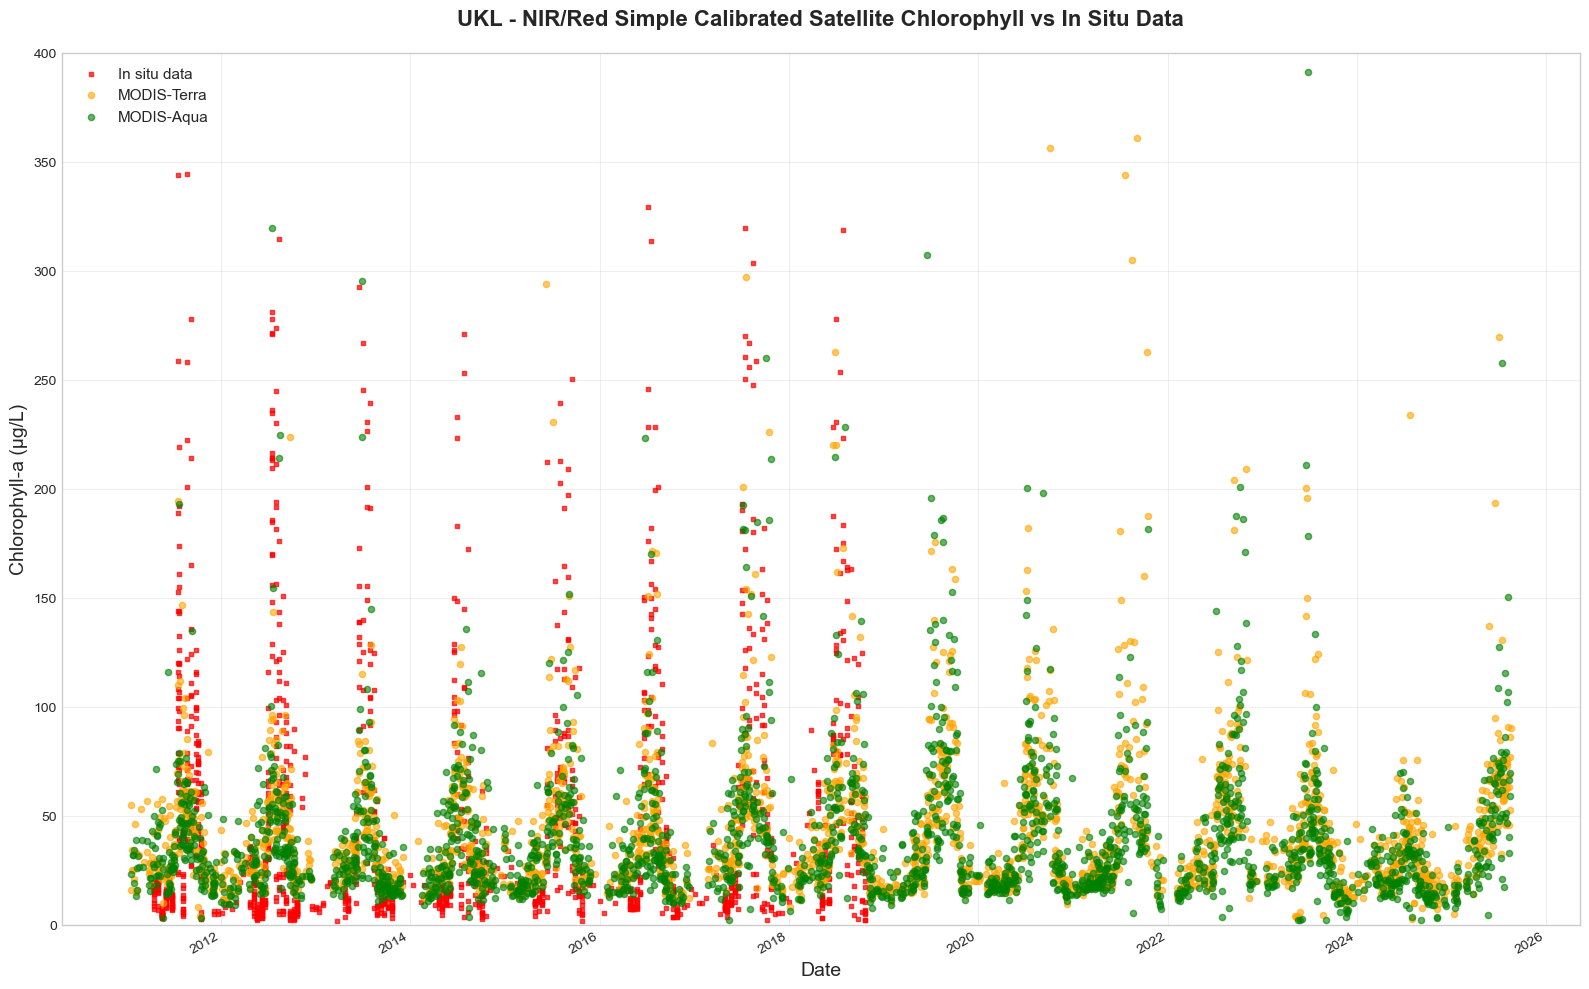

Plot saved: UKL_nirred_simple_comparison_time_series.png

Creating Multi-term time series plot for Detroit...


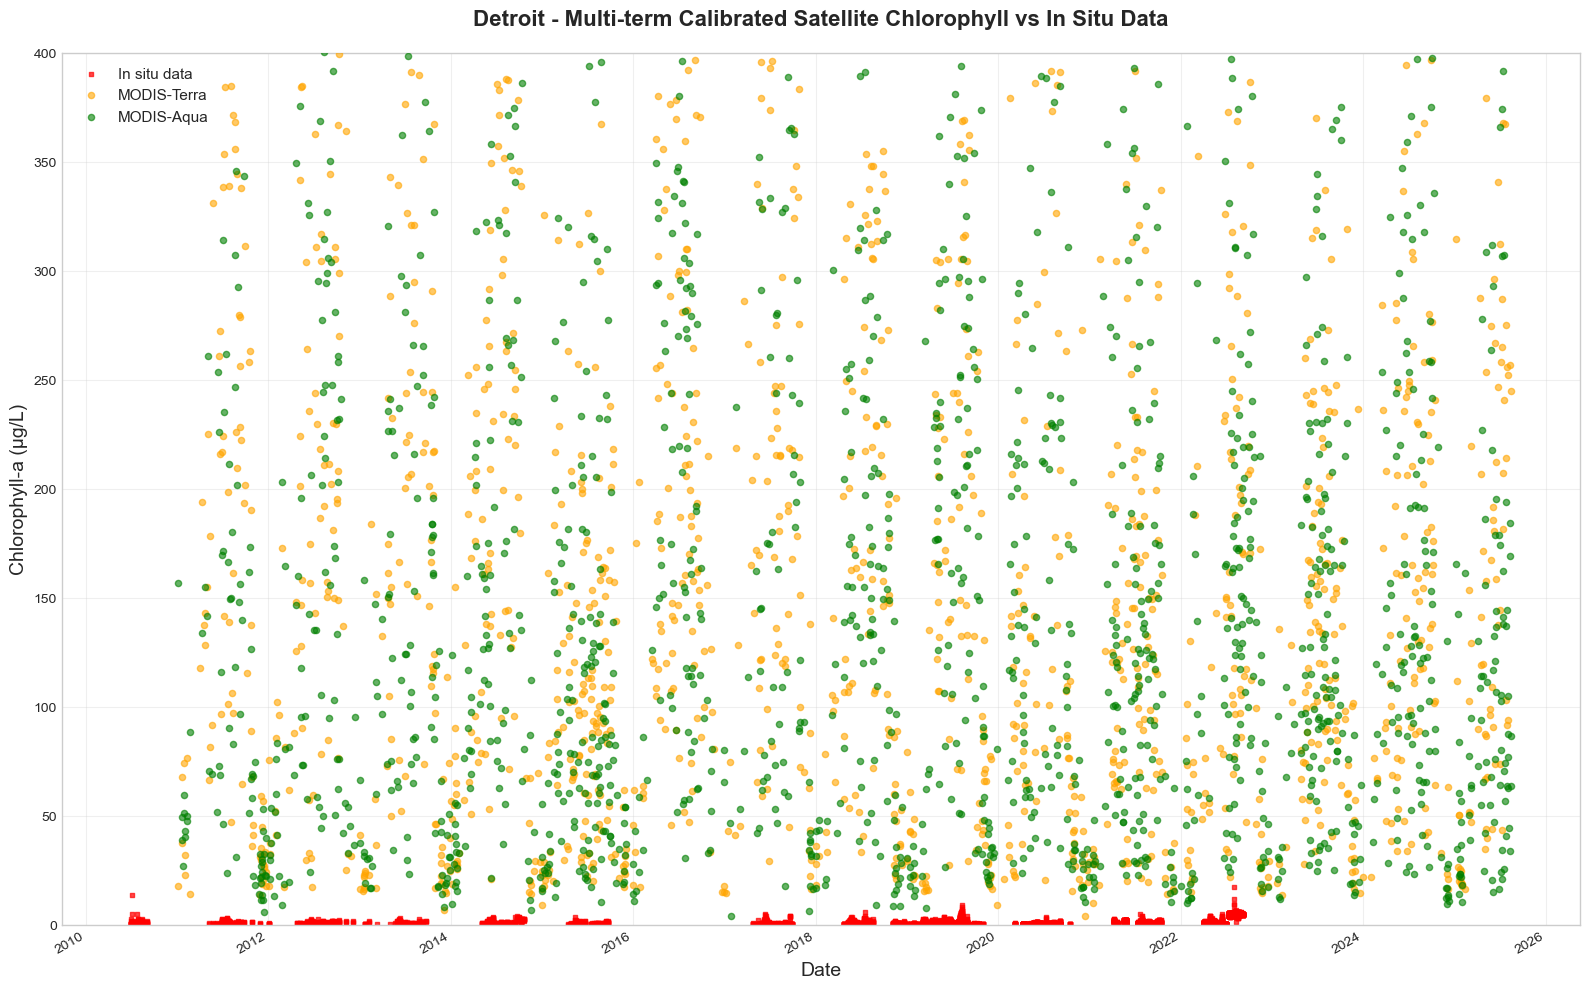

Plot saved: Detroit_multiterm_comparison_time_series.png

Creating Green/Red Log time series plot for Detroit...


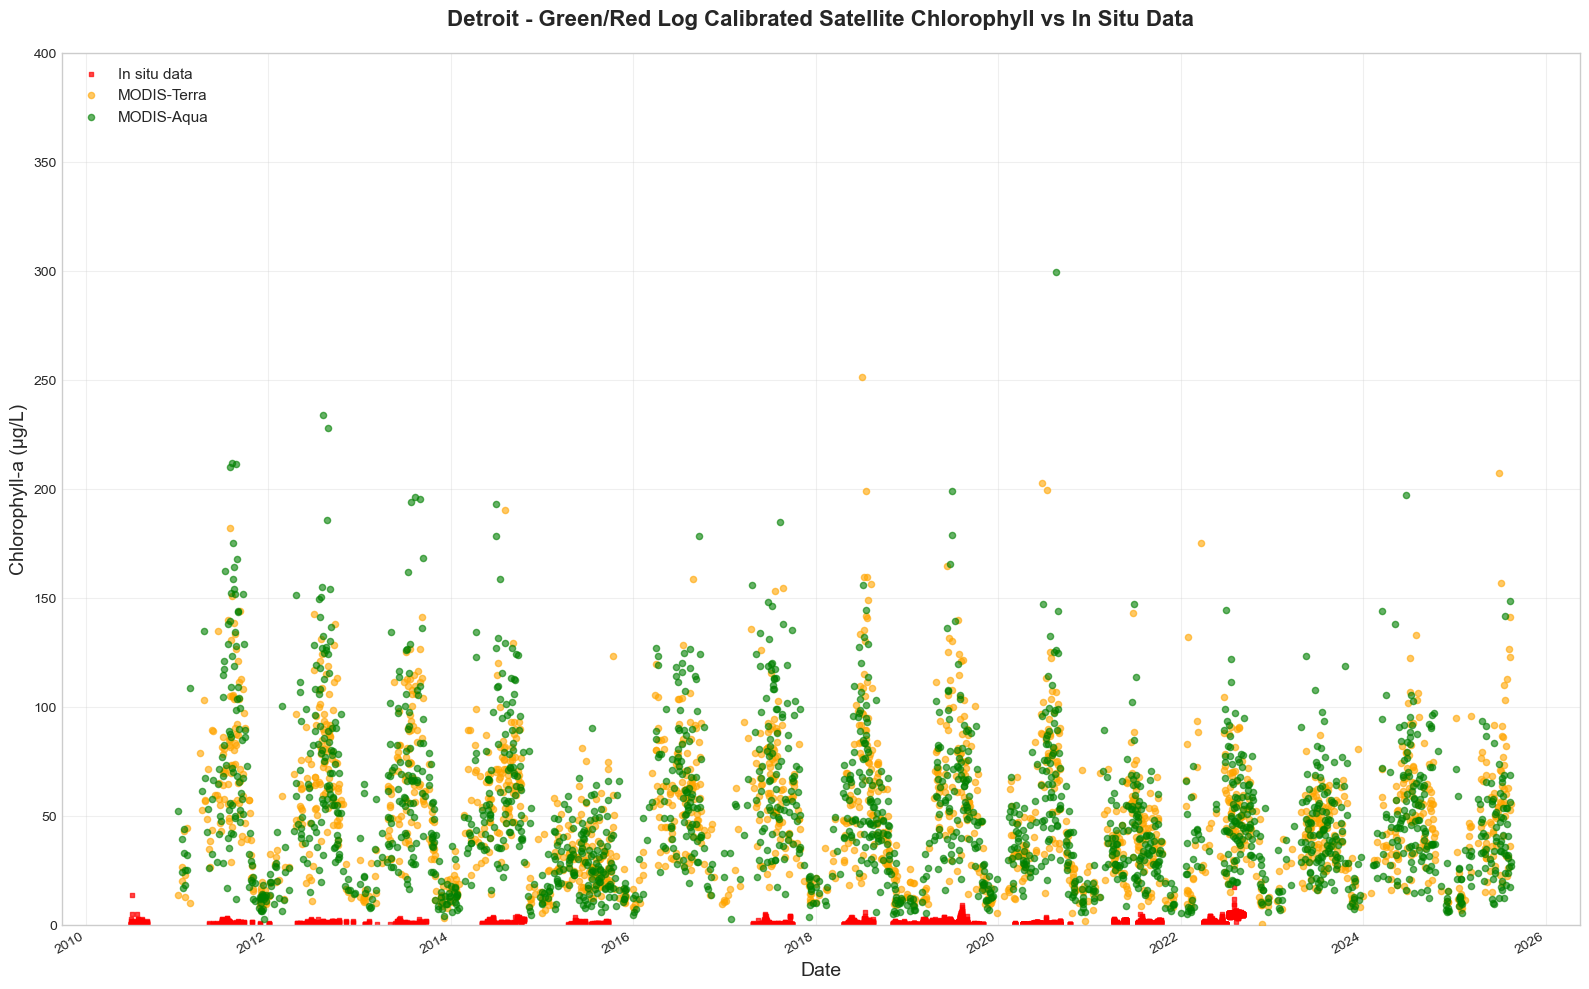

Plot saved: Detroit_greenred_log_comparison_time_series.png

Creating Green/Red Simple time series plot for Detroit...


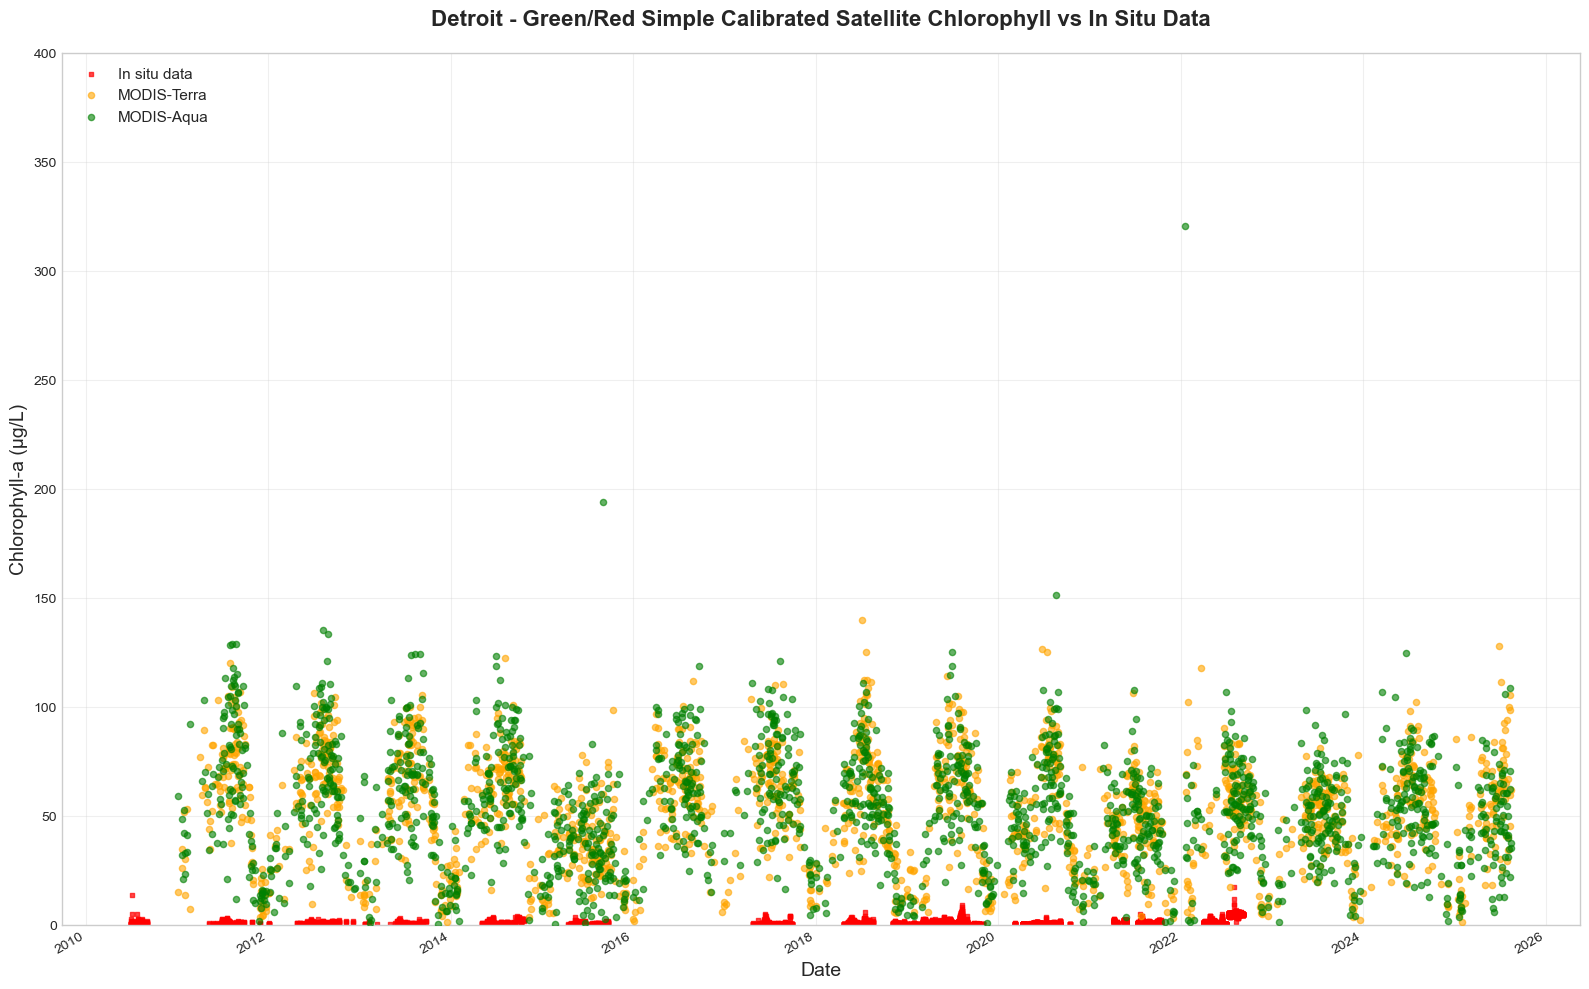

Plot saved: Detroit_greenred_simple_comparison_time_series.png

Creating NIR/Red Simple time series plot for Detroit...


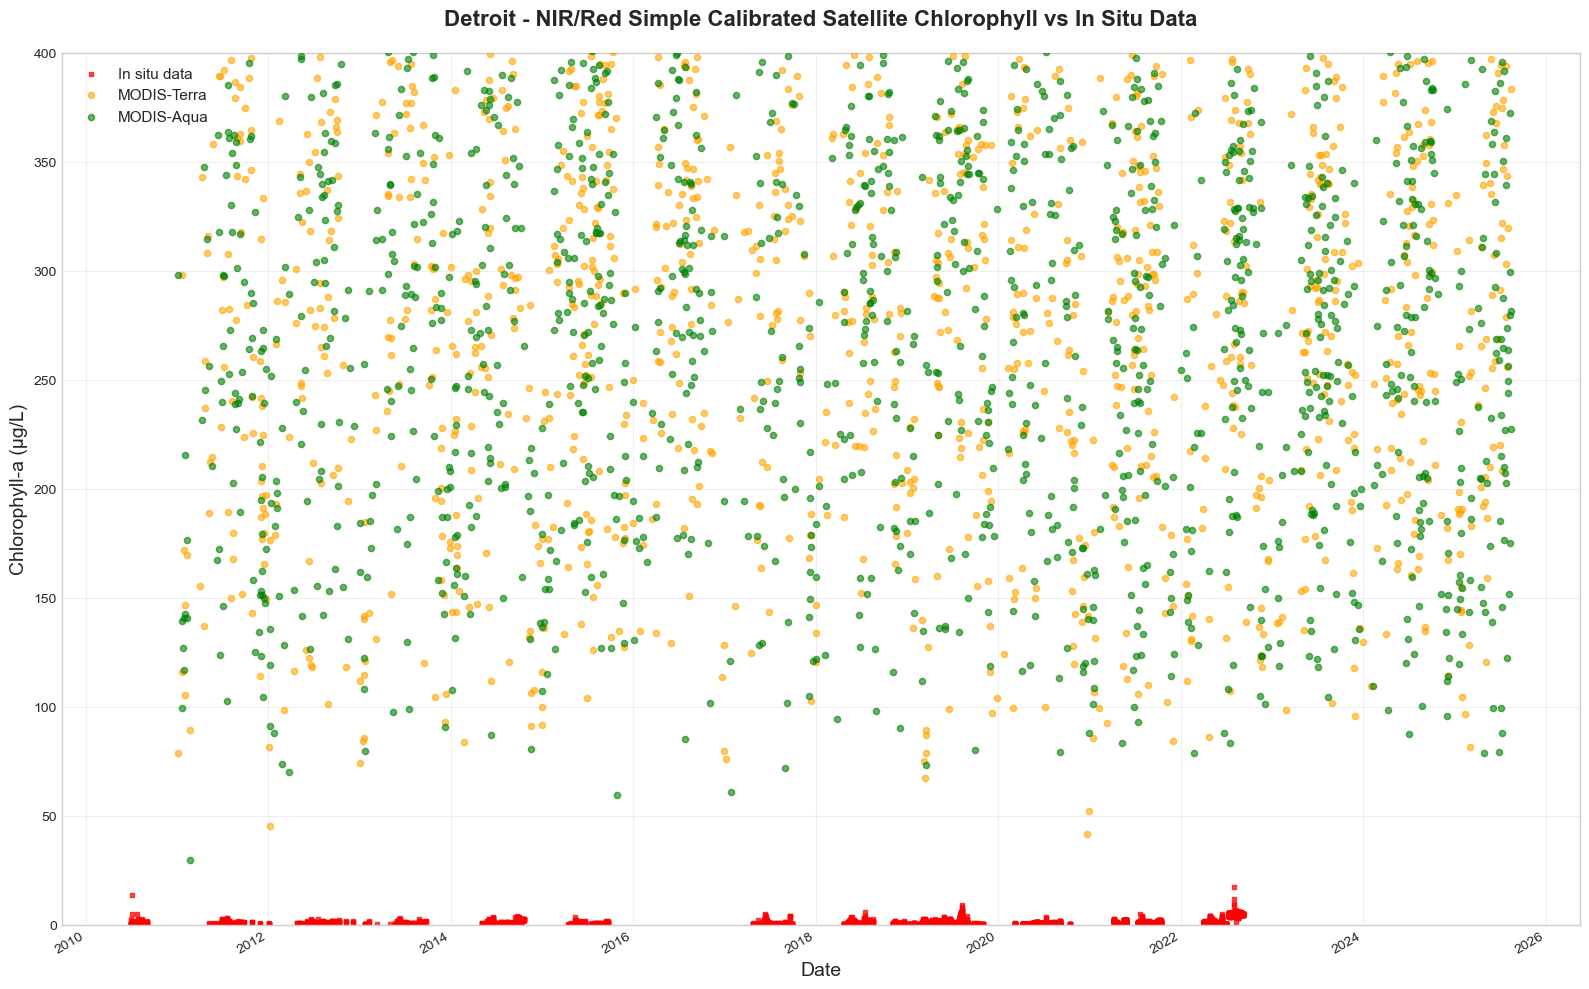

Plot saved: Detroit_nirred_simple_comparison_time_series.png


In [8]:
# Create comparison time series plots for each algorithm
def create_algorithm_comparison_plots(all_calibrated_data, insitu_data, lake_name):
    """Create time series plots comparing all algorithms"""
    
    if not all_calibrated_data:
        print(f"No calibrated data available for {lake_name}")
        return
    
    algorithms_to_plot = ['multiterm', 'greenred_log', 'greenred_simple', 'nirred_simple']
    algorithm_names = {
        'multiterm': 'Multi-term',
        'greenred_log': 'Green/Red Log',
        'greenred_simple': 'Green/Red Simple',
        'nirred_simple': 'NIR/Red Simple'
    }
    
    for alg_name in algorithms_to_plot:
        print(f"\nCreating {algorithm_names[alg_name]} time series plot for {lake_name}...")
        
        # Prepare data dictionary for this algorithm
        method_data = {}
        
        for sensor_name, sensor_results in all_calibrated_data.items():
            if alg_name in sensor_results and sensor_results[alg_name] is not None:
                df = sensor_results[alg_name]
                if f'chl_{alg_name}' in df.columns:
                    # Create a clean dataset for plotting
                    plot_df = df[['datetime', f'chl_{alg_name}']].copy()
                    plot_df = plot_df.rename(columns={f'chl_{alg_name}': 'chl_calibrated'})
                    plot_df = plot_df.dropna(subset=['chl_calibrated'])
                    
                    # Map sensor names to standard format
                    if 'Terra' in sensor_name:
                        method_data['MODIS-Terra'] = plot_df
                    elif 'Aqua' in sensor_name:
                        method_data['MODIS-Aqua'] = plot_df
        
        # Create the plot if we have data
        if method_data:
            title = f'{lake_name} - {algorithm_names[alg_name]} Calibrated Satellite Chlorophyll vs In Situ Data'
            filename = f'{lake_name}_{alg_name}_comparison_time_series.png'
            
            create_time_series_plot(
                method_data,
                insitu_data,
                title,
                filename,
                lake_name,
                ylim=(0, 400)
            )
        else:
            print(f"No data available for {algorithm_names[alg_name]} method")

# Create comparison plots
if 'ukl_all_calibrated' in locals():
    create_algorithm_comparison_plots(ukl_all_calibrated, ukl_insitu, "UKL")
    
if 'detroit_all_calibrated' in locals():
    # For Detroit, include YSI data if available  
    detroit_insitu_for_plot = detroit_insitu if 'detroit_insitu' in locals() else None
    create_algorithm_comparison_plots(detroit_all_calibrated, detroit_insitu_for_plot, "Detroit")
else:
    print("Algorithm comparison data not available for time series plotting")

## 6. Create Multi-Term Time Series Visualizations

In [9]:
# The create_multiterm_time_series function is now imported from modis_calibration_utils
# Time series plots are created in the previous cell (cell 13)

## 7. Export Multi-Term Results

In [10]:
# Export multi-term calibrated data to CSV files
def export_multiterm_results(calibrated_data, lake_name):
    """Export multi-term calibration results to CSV files"""
    
    if not calibrated_data:
        print(f"No calibrated data available for export from {lake_name}")
        return []
    
    print(f"\nExporting multi-term results for {lake_name}...")
    
    exported_files = []
    
    for sensor_name, df in calibrated_data.items():
        if df is not None and 'chl_multiterm' in df.columns:
            # Create export dataframe
            export_df = df[['datetime', 'chl_multiterm']].copy()
            export_df = export_df.rename(columns={'chl_multiterm': 'chl_calibrated'})
            export_df = export_df.dropna(subset=['chl_calibrated'])
            
            if len(export_df) > 0:
                # Generate filename
                sensor_clean = sensor_name.replace('-', '_')
                filename = f'{lake_name}_{sensor_clean}_multiterm_calibrated_chlorophyll.csv'
                
                # Export to CSV
                export_df.to_csv(filename, index=False)
                exported_files.append(filename)
                
                print(f"  Exported {sensor_name}: {len(export_df)} records -> {filename}")
    
    return exported_files

# Export results
exported_multiterm_files = []

if 'ukl_multiterm_calibrated' in locals():
    ukl_files = export_multiterm_results(ukl_multiterm_calibrated, "UKL")
    exported_multiterm_files.extend(ukl_files)
    
if 'detroit_multiterm_calibrated' in locals():
    detroit_files = export_multiterm_results(detroit_multiterm_calibrated, "Detroit")
    exported_multiterm_files.extend(detroit_files)

if exported_multiterm_files:
    print(f"\nTotal files exported: {len(exported_multiterm_files)}")
else:
    print("No multi-term calibrated data available for export")

No multi-term calibrated data available for export


## 8. Multi-Term Calibration Summary and Comparison

In [11]:
# Comprehensive summary of multi-term calibration results
print("=" * 90)
print("ENHANCED MODIS MULTI-TERM CALIBRATION ANALYSIS - SUMMARY")
print("=" * 90)

if 'multiterm_calibration_results' in locals() and multiterm_calibration_results:
    print(f"\n📊 MULTI-TERM CALIBRATION RESULTS (5-day matching window)")
    print(f"Equation: log₁₀(Chl_insitu) = α₀ + α₁×log₁₀(B4/B1) + α₂×(B2/B1)")
    print("-" * 90)
    
    # Show results for each sensor/method
    for sensor_name, result in multiterm_calibration_results.items():
        print(f"\n🛰️  {sensor_name.upper()}:")
        print(f"   Equation: {result['equation']}")
        
        # Coefficients
        cleaned = result['cleaned']
        print(f"   Coefficients: α₀={cleaned['alpha0']:.3f}, α₁={cleaned['alpha1']:.3f}, α₂={cleaned['alpha2']:.3f}")
        
        # Performance metrics
        print(f"   Performance:")
        print(f"     Original R² = {result['original']['r2']:.3f} (n={result['original']['n_matches']})")
        print(f"     Cleaned R²  = {cleaned['r2']:.3f} (n={cleaned['n_matches']})")
        print(f"     RMSE = {cleaned['rmse']:.3f}")
        print(f"     Outliers removed: {result['outlier_results']['n_outliers_removed']}")
        print(f"     Improvement: ΔR² = {cleaned['r2'] - result['original']['r2']:+.3f}")
    
    # Show data matching statistics
    if 'ukl_matched_5day' in locals() and ukl_matched_5day is not None:
        print(f"\n📈 TEMPORAL MATCHING STATISTICS (5-day window):")
        print(f"   Total matched pairs: {len(ukl_matched_5day)}")
        print(f"   Average time difference: {ukl_matched_5day['time_diff_days'].mean():.1f} days")
        print(f"   Maximum time difference: {ukl_matched_5day['time_diff_days'].max():.1f} days")
        
        # Compare with different time windows (if available)
        same_day = (ukl_matched_5day['time_diff_days'] == 0).sum()
        within_1day = (ukl_matched_5day['time_diff_days'] <= 1).sum()
        within_3days = (ukl_matched_5day['time_diff_days'] <= 3).sum()
        
        print(f"   Temporal distribution:")
        print(f"     Same day: {same_day} ({same_day/len(ukl_matched_5day)*100:.1f}%)")
        print(f"     ≤ 1 day: {within_1day} ({within_1day/len(ukl_matched_5day)*100:.1f}%)")
        print(f"     ≤ 3 days: {within_3days} ({within_3days/len(ukl_matched_5day)*100:.1f}%)")
    
    # Show generated outputs
    print(f"\n📂 GENERATED OUTPUTS:")
    print(f"   ✓ Multi-term calibration analysis plots for each sensor")
    print(f"   ✓ Time series plots with multi-term calibrations")
    if 'exported_multiterm_files' in locals() and exported_multiterm_files:
        print(f"   ✓ CSV files with multi-term calibrated chlorophyll data:")
        for file in exported_multiterm_files:
            print(f"     - {file}")
    
    # Recommendations
    print(f"\n🎯 RECOMMENDATIONS:")
    
    # Find best performing method
    best_sensor = max(multiterm_calibration_results.keys(), 
                     key=lambda x: multiterm_calibration_results[x]['cleaned']['r2'])
    best_r2 = multiterm_calibration_results[best_sensor]['cleaned']['r2']
    
    print(f"   ✓ Best performing sensor: {best_sensor} (R² = {best_r2:.3f})")
    print(f"   ✓ Multi-term model shows improved performance with additional NIR/Red term")
    print(f"   ✓ 5-day matching window captures more satellite-insitu pairs")
    print(f"   ✓ Use outlier-cleaned calibrations for final applications")
    print(f"   ✓ Monitor predictions outside the calibration range")
    
    # Show equation for best method
    best_result = multiterm_calibration_results[best_sensor]
    print(f"\n🏆 RECOMMENDED EQUATION ({best_sensor}):")
    print(f"   {best_result['equation']}")

else:
    print(f"\n❌ NO MULTI-TERM CALIBRATION RESULTS GENERATED")
    print(f"Please check:")
    print(f"   - Data file paths are correct")
    print(f"   - Satellite data contains required bands (B1_red, B2_nir, B4_green)")
    print(f"   - In situ data is available and properly formatted")
    print(f"   - Temporal overlap exists between satellite and in situ data")

print("\n" + "=" * 90)
print("🎉 MULTI-TERM CALIBRATION ANALYSIS COMPLETE!")
print("=" * 90)

ENHANCED MODIS MULTI-TERM CALIBRATION ANALYSIS - SUMMARY

❌ NO MULTI-TERM CALIBRATION RESULTS GENERATED
Please check:
   - Data file paths are correct
   - Satellite data contains required bands (B1_red, B2_nir, B4_green)
   - In situ data is available and properly formatted
   - Temporal overlap exists between satellite and in situ data

🎉 MULTI-TERM CALIBRATION ANALYSIS COMPLETE!
